In [66]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\USER\PycharmProjects\component2_traffic\traffic_simulation\final_dataset_adaptive.csv")

In [67]:
# Quick preview
print(df.head()) 


   vehicle_id system_type  depart_time  arrival_time  duration  waiting_time  \
0           0    adaptive          0.0          68.0      68.0           0.0   
1          22    adaptive         33.0         125.0      92.0           0.0   
2          28    adaptive         42.0         129.0      87.0           0.0   
3          40    adaptive         60.0         146.0      86.0           0.0   
4          23    adaptive         35.0         181.0     146.0          45.0   

   time_loss  route_length  average_speed  waiting_ratio  delay_ratio  
0       7.87        863.15      12.693382       0.000000     0.115735  
1      10.57        681.20       7.404348       0.000000     0.114891  
2       9.68        719.84       8.274023       0.000000     0.111264  
3      10.72        724.48       8.424186       0.000000     0.124651  
4      67.34        674.91       4.622671       0.308219     0.461233  


In [68]:
# Dataset summary
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 1841 entries, 0 to 1840
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   vehicle_id     1841 non-null   int64  
 1   system_type    1841 non-null   str    
 2   depart_time    1841 non-null   float64
 3   arrival_time   1841 non-null   float64
 4   duration       1841 non-null   float64
 5   waiting_time   1841 non-null   float64
 6   time_loss      1841 non-null   float64
 7   route_length   1841 non-null   float64
 8   average_speed  1841 non-null   float64
 9   waiting_ratio  1841 non-null   float64
 10  delay_ratio    1841 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 158.3 KB
None


In [69]:
# Statistical summary
print(df.describe())

        vehicle_id  depart_time  arrival_time     duration  waiting_time  \
count  1841.000000  1841.000000   1841.000000  1841.000000   1841.000000   
mean   1040.184682  1560.730038   1970.801195   410.071157    147.159153   
std     629.592199   944.419617    943.292827   348.833307    305.080275   
min       0.000000     0.000000     68.000000     8.000000      0.000000   
25%     498.000000   747.000000   1186.000000   226.000000     15.000000   
50%    1017.000000  1526.000000   1977.000000   344.000000     73.000000   
75%    1574.000000  2361.000000   2774.000000   488.000000    147.000000   
max    2338.000000  3507.000000   3596.000000  3458.000000   3052.000000   

         time_loss  route_length  average_speed  waiting_ratio  delay_ratio  
count  1841.000000   1841.000000    1841.000000    1841.000000  1841.000000  
mean    206.814193   2638.331233       7.522252       0.239100     0.401308  
std     319.103126   1247.211684       2.184430       0.202167     0.197177  
min

In [70]:
#Check Missing Values
print(df.isnull().sum())

vehicle_id       0
system_type      0
depart_time      0
arrival_time     0
duration         0
waiting_time     0
time_loss        0
route_length     0
average_speed    0
waiting_ratio    0
delay_ratio      0
dtype: int64


In [71]:
df.fillna(df.median(numeric_only=True), inplace=True)

,vehicle_id,system_type,depart_time,arrival_time,duration,waiting_time,time_loss,route_length,average_speed,waiting_ratio,delay_ratio
0,0,adaptive,0.0,68.0,68.0,0.0,7.87,863.15,12.693382,0.000000,0.115735
1,22,adaptive,33.0,125.0,92.0,0.0,10.57,681.20,7.404348,0.000000,0.114891
2,28,adaptive,42.0,129.0,87.0,0.0,9.68,719.84,8.274023,0.000000,0.111264
3,40,adaptive,60.0,146.0,86.0,0.0,10.72,724.48,8.424186,0.000000,0.124651
4,23,adaptive,35.0,181.0,146.0,45.0,67.34,674.91,4.622671,0.308219,0.461233
...,...,...,...,...,...,...,...,...,...,...,...
1836,2131,adaptive,3197.0,3588.0,391.0,4.0,47.83,3455.16,8.836726,0.010230,0.122327
1837,1241,adaptive,1862.0,3594.0,1732.0,1518.0,1557.75,2481.41,1.432685,0.876443,0.899394
1838,1947,adaptive,2921.0,3594.0,673.0,151.0,322.10,5062.87,7.522838,0.224368,0.478603
1839,2181,adaptive,3272.0,3595.0,323.0,133.0,204.43,2114.82,6.547430,0.411765,0.632910


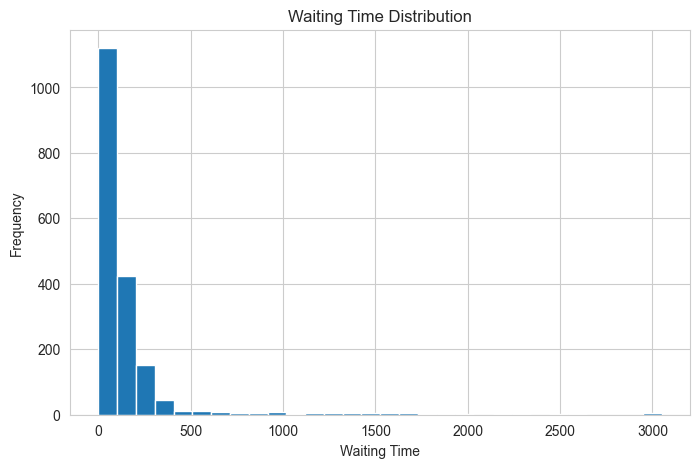

In [72]:
plt.figure(figsize=(8,5))
plt.hist(df["waiting_time"], bins=30)
plt.xlabel("Waiting Time")
plt.ylabel("Frequency")
plt.title("Waiting Time Distribution")
plt.show()

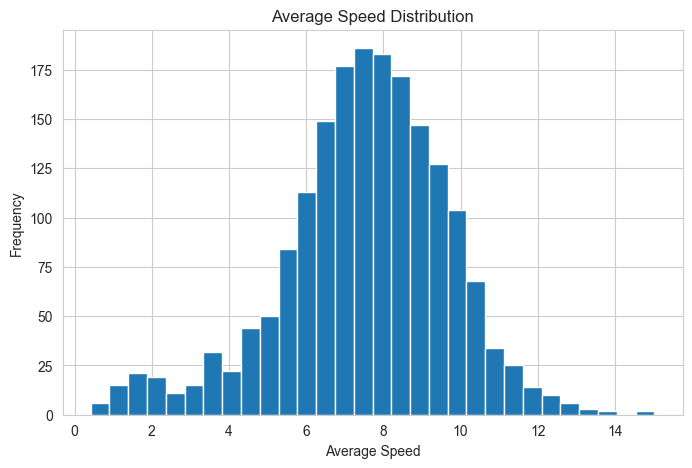

In [73]:
plt.figure(figsize=(8,5))
plt.hist(df["average_speed"], bins=30)
plt.xlabel("Average Speed")
plt.ylabel("Frequency")
plt.title("Average Speed Distribution")
plt.show()

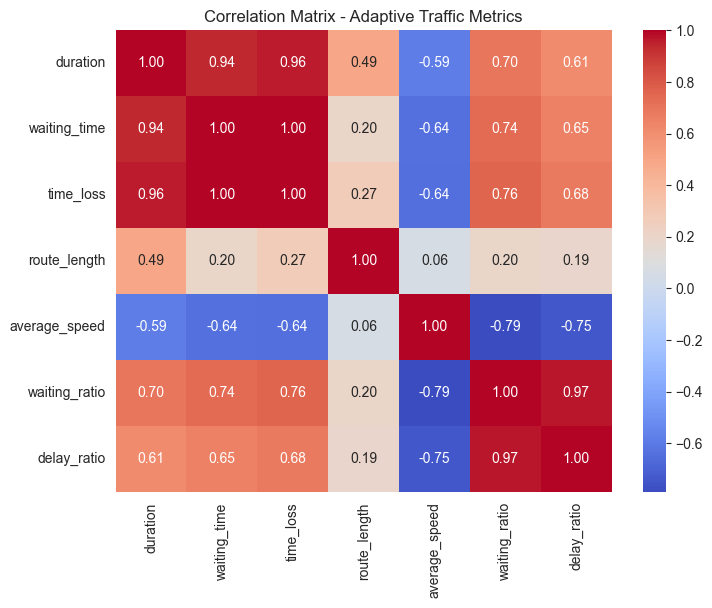

In [74]:
import seaborn as sns

cols = [
    "duration",
    "waiting_time",
    "time_loss",
    "route_length",
    "average_speed",
    "waiting_ratio",
    "delay_ratio"
]

corr_matrix = df[cols].corr()

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Adaptive Traffic Metrics")
plt.show()


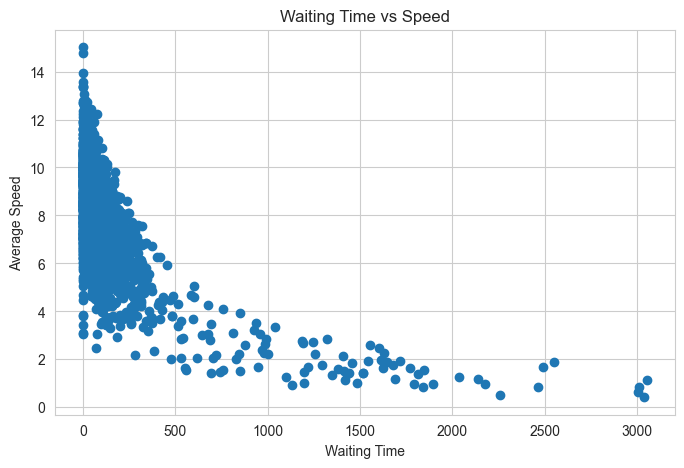

In [75]:
plt.figure(figsize=(8,5))
plt.scatter(df["waiting_time"], df["average_speed"])
plt.xlabel("Waiting Time")
plt.ylabel("Average Speed")
plt.title("Waiting Time vs Speed")
plt.show()

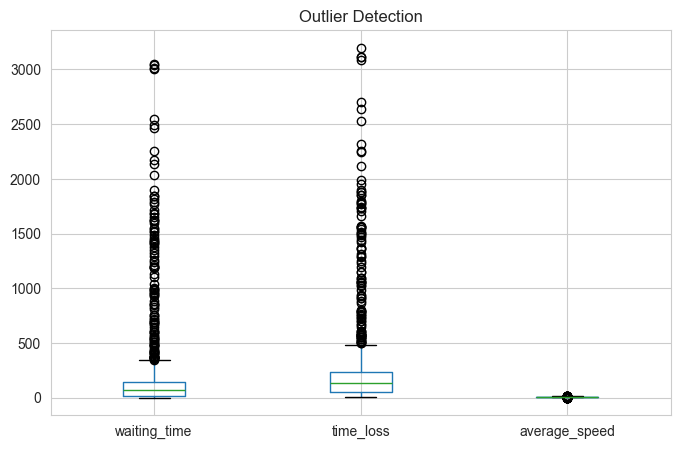

In [76]:
#Outlier Detection
plt.figure(figsize=(8,5))
df[["waiting_time","time_loss","average_speed"]].boxplot()
plt.title("Outlier Detection")
plt.show()